# Capstone Assignment: Credit Card Fraud Detection
### CS2227: Artificial Intelligence and Machine Learning

---

## Problem Statement

Real-world credit card datasets are **massively imbalanced** — typically only ~0.17% of transactions
are fraudulent. This means a naive model that predicts "Legitimate" for every transaction would
achieve 99.83% accuracy — yet catch **zero fraud cases**. This is the **Accuracy Paradox**.

Our pipeline synthesizes both labs:
- **Lab 4 (SMOTE):** Correct the class imbalance in the training set
- **Lab 5 (SVM + RBF Kernel):** Handle the non-linear decision boundary between fraud and legitimate transactions

## Pipeline Overview

```
Raw Dataset
    │
    ├─── EDA (prove imbalance)
    │
    ├─── Train / Test Split  ← SMOTE applied AFTER this step only
    │         │
    │    X_train, y_train ──► SMOTE ──► X_train_resampled
    │    X_test,  y_test  ──► (untouched, real-world distribution preserved)
    │
    ├─── StandardScaler (fit on train, transform both)
    │
    ├─── Model 1: Logistic Regression
    ├─── Model 2: SVM with RBF Kernel
    │
    └─── Evaluation: Precision, Recall, F1-Score (NOT Accuracy)
```

---

## Why NOT Accuracy?

With 99.83% legitimate transactions, a model predicting all-legitimate gets **99.83% accuracy**
but **0% Recall on fraud** — it catches nothing. We use:

- **Precision** = Of all transactions flagged as fraud, how many actually were?
  → Minimizes false alarms (customer inconvenience)
- **Recall** = Of all actual frauds, how many did we catch?
  → Minimizes missed fraud (financial loss)
- **F1-Score** = Harmonic mean of Precision and Recall
  → Balanced view when classes are imbalanced

> **For a bank, Recall is more important than Precision.**
> Missing a fraud case (False Negative) costs the bank real money and destroys customer trust.
> A false alarm (False Positive) is inconvenient but recoverable — the customer can confirm the transaction.

---
## Step 1: Install & Import Libraries

In [2]:
!pip install imbalanced-learn -q
!pip install kagglehub -q

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE


---
## Step 2: Load the Dataset

We use the **Credit Card Fraud Detection** dataset from Kaggle (by ULB Machine Learning Group).
It contains 284,807 transactions made by European cardholders in September 2013.
Only 492 (0.172%) are fraudulent.

Features V1–V28 are PCA-transformed (anonymised for privacy). Only `Time` and `Amount` are raw.
`Class` is the target: 0 = Legitimate, 1 = Fraud.

In [4]:
import kagglehub

try:
    path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
    df = pd.read_csv(f"{path}/creditcard.csv")
    print(f"Dataset loaded via kagglehub from: {path}")
except Exception as e:
    print(f"kagglehub failed: {e}")
    print("Trying fallback: upload creditcard.csv manually and run:")
    print("  df = pd.read_csv('creditcard.csv')")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset loaded via kagglehub from: /kaggle/input/creditcardfraud

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## Step 3: Exploratory Data Analysis (EDA)

Before modelling, we must **understand and visualize** the data — especially the class imbalance.

In [5]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total transactions : {len(df):,}")
print(f"Total features     : {df.shape[1]}")
print(f"Missing values     : {df.isnull().sum().sum()}")
print(f"Data types         : {df.dtypes.value_counts().to_dict()}")

print("\n--- Class Distribution ---")
class_counts = df['Class'].value_counts()
print(f"  Legitimate (0) : {class_counts[0]:,} ({class_counts[0]/len(df)*100:.4f}%)")
print(f"  Fraud      (1) : {class_counts[1]:,} ({class_counts[1]/len(df)*100:.4f}%)")
print(f"  Imbalance Ratio: {class_counts[0]/class_counts[1]:.0f}:1  (legitimate:fraud)")

DATASET OVERVIEW
Total transactions : 284,807
Total features     : 31
Missing values     : 0
Data types         : {dtype('float64'): 30, dtype('int64'): 1}

--- Class Distribution ---
  Legitimate (0) : 284,315 (99.8273%)
  Fraud      (1) : 492 (0.1727%)
  Imbalance Ratio: 578:1  (legitimate:fraud)


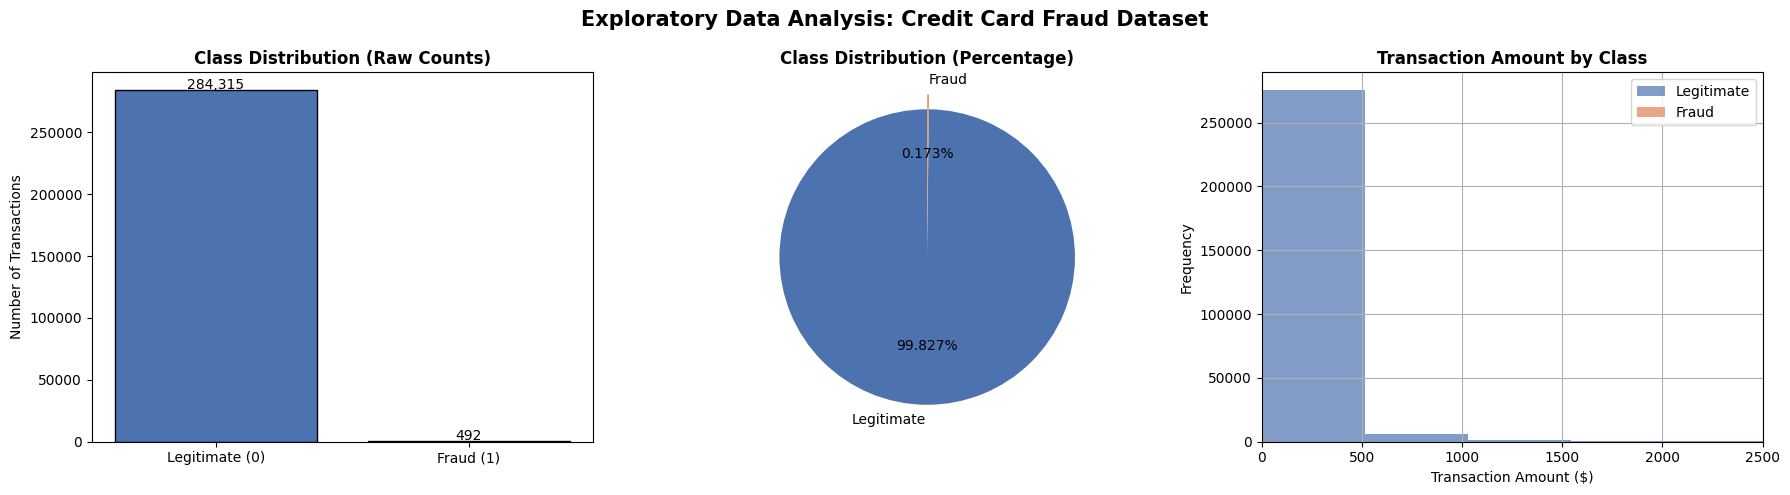

Observation: The dataset is severely imbalanced — fraud accounts for only 0.172% of transactions.
A naive 'predict-all-legitimate' model would achieve 99.83% accuracy but catch ZERO frauds.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis: Credit Card Fraud Dataset', fontsize=15, fontweight='bold')

colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Raw Counts)', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', fontsize=10)

axes[1].pie(
    class_counts.values,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.3f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Class Distribution (Percentage)', fontweight='bold')

df[df['Class'] == 0]['Amount'].hist(ax=axes[2], bins=50, alpha=0.7, color='#4C72B0', label='Legitimate')
df[df['Class'] == 1]['Amount'].hist(ax=axes[2], bins=50, alpha=0.7, color='#DD8452', label='Fraud')
axes[2].set_title('Transaction Amount by Class', fontweight='bold')
axes[2].set_xlabel('Transaction Amount ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].set_xlim(0, 2500)

plt.tight_layout()
plt.show()

print("Observation: The dataset is severely imbalanced — fraud accounts for only 0.172% of transactions.")
print("A naive 'predict-all-legitimate' model would achieve 99.83% accuracy but catch ZERO frauds.")

In [7]:
print("--- Mean Feature Values: Fraud vs Legitimate ---")
comparison = df.groupby('Class')[['Amount', 'V1', 'V2', 'V3', 'V4', 'V14', 'V17']].mean()
comparison.index = ['Legitimate', 'Fraud']
print(comparison.round(3))

print("\nObservation: Features like V14 and V17 show large differences between classes,")
print("suggesting non-linear boundaries that SVM with RBF kernel is well-suited to capture.")

--- Mean Feature Values: Fraud vs Legitimate ---
             Amount     V1     V2     V3     V4    V14    V17
Legitimate   88.291  0.008 -0.006  0.012 -0.008  0.012  0.012
Fraud       122.211 -4.772  3.624 -7.033  4.542 -6.972 -6.666

Observation: Features like V14 and V17 show large differences between classes,
suggesting non-linear boundaries that SVM with RBF kernel is well-suited to capture.


---
## Step 4: Train/Test Split

We split **before** applying SMOTE. This is the most critical data hygiene rule:

> If SMOTE is applied before the split, synthetic points derived from test-set neighbors can enter
> the training set. This causes **data leakage** — the model has indirect knowledge of the test set,
> producing artificially inflated metrics that won't hold in production.

In [8]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set  : {X_train.shape[0]:,} samples")
print(f"Fraud           : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test set        : {X_test.shape[0]:,} samples")
print(f"Fraud           : {y_test.sum():,} ({y_test.mean()*100:.3f}%)")
print("\nSplit done. SMOTE will only be applied to X_train/y_train next.")

Feature matrix shape : (284807, 29)
Target vector shape  : (284807,)

Training set  : 227,845 samples
Fraud           : 394 (0.173%)
Test set        : 56,962 samples
Fraud           : 98 (0.172%)

Split done. SMOTE will only be applied to X_train/y_train next.


---
## Step 5: Apply SMOTE to Training Set Only

SMOTE is applied **exclusively to `X_train` and `y_train`**. The test set remains completely untouched,
preserving the real-world class distribution for honest evaluation.

In [9]:
smote = SMOTE(
    sampling_strategy='minority',
    random_state=42,
    k_neighbors=5
)

print("Applying SMOTE to training set...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE → {Counter(y_train)}")
print(f"After  SMOTE → {Counter(y_train_smote)}")
print(f"\nSynthetic fraud samples created: {Counter(y_train_smote)[1] - Counter(y_train)[1]:,}")
print("\nTest set is untouched — no data leakage.")
print(f"Test set fraud count: {y_test.sum()} ({y_test.mean()*100:.3f}%) — real-world distribution preserved.")

Applying SMOTE to training set...

Before SMOTE → Counter({0: 227451, 1: 394})
After  SMOTE → Counter({0: 227451, 1: 227451})

Synthetic fraud samples created: 227,057

Test set is untouched — no data leakage.
Test set fraud count: 98 (0.172%) — real-world distribution preserved.


---
## Step 6: Feature Scaling with StandardScaler

StandardScaler is **mandatory** before SVM. SVM uses Euclidean distances $\|x - x'\|^2$;
unscaled features with larger ranges (like `Amount` in dollars) would dominate the distance
calculation, effectively making other features invisible.

We also scale for Logistic Regression — it helps gradient descent converge faster and avoids
numerical instability with regularization.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled  = scaler.transform(X_test)

print("Scaling applied.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean(axis=0)[:3].round(4)}...")
print(f"Training set std  (should be ~1): {X_train_scaled.std(axis=0)[:3].round(4)}...")
print(f"\nFinal shapes:")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")

Scaling applied.
Training set mean (should be ~0): [-0.  0.  0.]...
Training set std  (should be ~1): [1. 1. 1.]...

Final shapes:
X_train_scaled : (454902, 29)
X_test_scaled  : (56962, 29)


---
## Step 7: Train the Models

We train two classifiers:
1. **Logistic Regression** — a linear probabilistic classifier (baseline)
2. **SVM with RBF Kernel** — a powerful non-linear classifier

Both are trained on the SMOTE-balanced, scaled training data.

In [11]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train_smote)
print("Logistic Regression trained.")

Logistic Regression trained.


In [12]:
print("Training SVM with RBF Kernel..")
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train_smote)
print("SVM (RBF) trained.")

Training SVM with RBF Kernel..
SVM (RBF) trained.


---
## Step 8: Evaluation — Precision, Recall, and F1-Score

> **Accuracy is forbidden here.** Due to the accuracy paradox, a model predicting all transactions
> as legitimate would score 99.83% accuracy while catching 0% of fraud.
>
> We evaluate using `classification_report` which provides:
> - **Precision** = TP / (TP + FP) — of flagged frauds, how many were real?
> - **Recall** = TP / (TP + FN) — of real frauds, how many did we catch?
> - **F1-Score** = 2 × (P × R) / (P + R) — harmonic balance of both

In [13]:
lr_preds = lr_model.predict(X_test_scaled)

print("=" * 55)
print("MODEL 1: LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(
    y_test, lr_preds,
    target_names=['Legitimate (0)', 'Fraud (1)']
))

lr_precision = precision_score(y_test, lr_preds)
lr_recall    = recall_score(y_test, lr_preds)
lr_f1        = f1_score(y_test, lr_preds)
print(f"Fraud Class → Precision: {lr_precision:.4f} | Recall: {lr_recall:.4f} | F1: {lr_f1:.4f}")

MODEL 1: LOGISTIC REGRESSION — Classification Report
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99     56864
     Fraud (1)       0.08      0.91      0.14        98

      accuracy                           0.98     56962
     macro avg       0.54      0.94      0.57     56962
  weighted avg       1.00      0.98      0.99     56962

Fraud Class → Precision: 0.0773 | Recall: 0.9082 | F1: 0.1425


In [14]:
svm_preds = svm_model.predict(X_test_scaled)

print("=" * 55)
print("MODEL 2: SVM (RBF KERNEL) — Classification Report")
print("=" * 55)
print(classification_report(
    y_test, svm_preds,
    target_names=['Legitimate (0)', 'Fraud (1)']
))

svm_precision = precision_score(y_test, svm_preds)
svm_recall    = recall_score(y_test, svm_preds)
svm_f1        = f1_score(y_test, svm_preds)
print(f"Fraud Class → Precision: {svm_precision:.4f} | Recall: {svm_recall:.4f} | F1: {svm_f1:.4f}")

MODEL 2: SVM (RBF KERNEL) — Classification Report
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
     Fraud (1)       0.29      0.73      0.41        98

      accuracy                           1.00     56962
     macro avg       0.64      0.87      0.70     56962
  weighted avg       1.00      1.00      1.00     56962

Fraud Class → Precision: 0.2857 | Recall: 0.7347 | F1: 0.4114


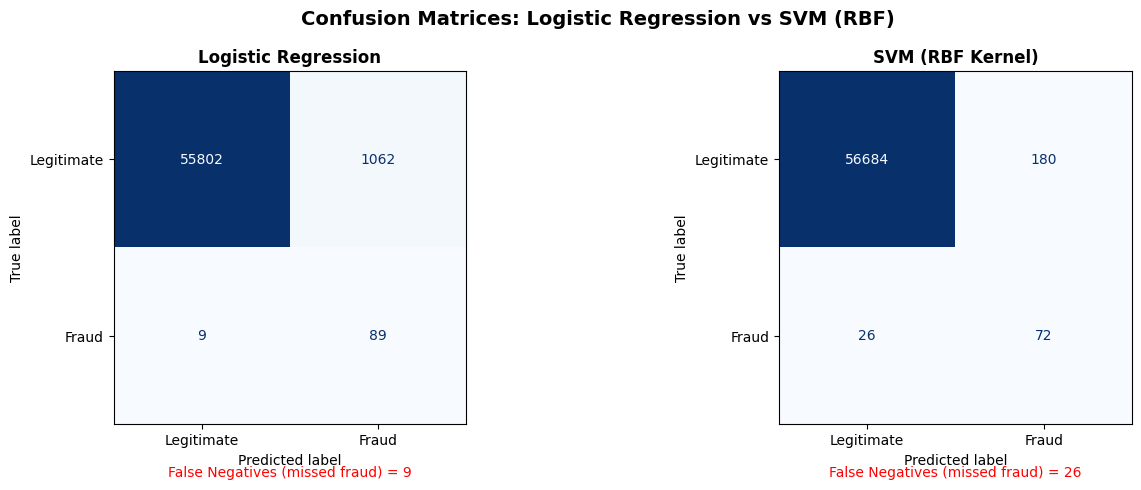

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices: Logistic Regression vs SVM (RBF)', fontsize=14, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [lr_preds, svm_preds],
    ['Logistic Regression', 'SVM (RBF Kernel)']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.text(0.5, -0.15, f"False Negatives (missed fraud) = {cm[1][0]}",
            transform=ax.transAxes, ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.show()

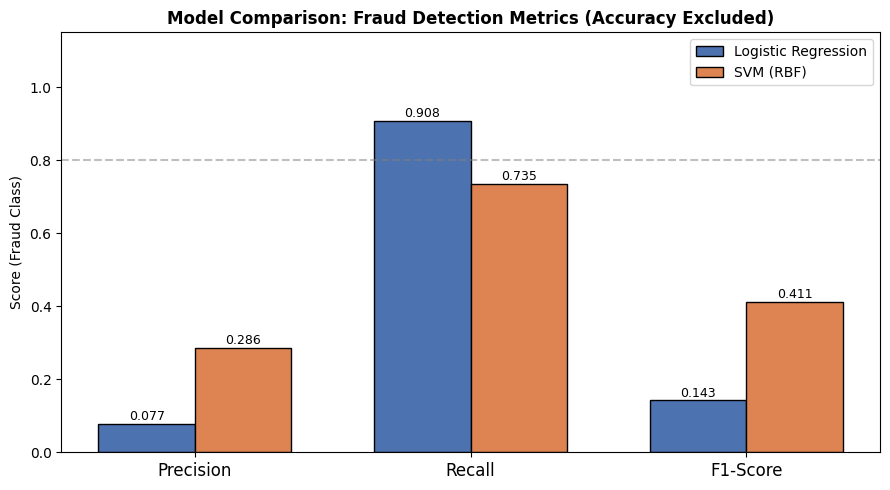


Final Comparison:
Metric         Logistic Reg    SVM (RBF)
----------------------------------------
Precision            0.0773       0.2857  <-- better
Recall               0.9082       0.7347  
F1-Score             0.1425       0.4114  <-- better


In [16]:

metrics     = ['Precision', 'Recall', 'F1-Score']
lr_scores   = [lr_precision,  lr_recall,  lr_f1]
svm_scores  = [svm_precision, svm_recall, svm_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores,  width, label='Logistic Regression', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM (RBF)',           color='#DD8452', edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score (Fraud Class)')
ax.set_title('Model Comparison: Fraud Detection Metrics (Accuracy Excluded)', fontweight='bold')
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
plt.tight_layout()
plt.show()

print(f"\nFinal Comparison:")
print(f"{'Metric':<12} {'Logistic Reg':>14} {'SVM (RBF)':>12}")
print("-" * 40)
for m, l, s in zip(metrics, lr_scores, svm_scores):
    winner = '<-- better' if s > l else ''
    print(f"{m:<12} {l:>14.4f} {s:>12.4f}  {winner}")

---
## Step 9: Critical Analysis

### Why Did SVM (RBF) Outperform Logistic Regression?

**Logistic Regression** models the decision boundary as a linear hyperplane:
$$P(\text{Fraud} | x) = \sigma(w^T x + b)$$
This assumes that fraudulent and legitimate transactions are **linearly separable** in feature space.
In reality, the V1–V28 PCA-transformed features from real transaction patterns create **curved, non-linear
boundaries** between classes. Logistic Regression can approximate this with regularization, but it is
fundamentally constrained to a flat hyperplane.

**SVM with RBF Kernel** uses:
$$K(x, x') = \exp(-\gamma \|x - x'\|^2)$$
This kernel implicitly projects the data into an **infinite-dimensional** feature space where the
fraudulent cluster can be separated from legitimate transactions by a hyperplane — even if no such
plane exists in the original 29-dimensional space. The RBF kernel effectively measures **local similarity**
— nearby points in the original space have high kernel values, while distant points approach zero.
This allows the model to draw **smooth, curved islands** around fraud clusters.

In the original feature space, fraud patterns likely appear as **concentrated clusters** scattered
within the larger legitimate transaction manifold. The RBF kernel's Gaussian similarity measure
is perfectly suited to isolate such local concentrations.

---

### Why Is Recall More Important Than Precision for Fraud Detection?

Consider the two types of errors a fraud model can make:

| Error Type | What Happens | Consequence |
|------------|-------------|-------------|
| **False Positive** (Low Precision) | Legitimate transaction flagged as fraud | Customer is notified; minor inconvenience; transaction verified and cleared |
| **False Negative** (Low Recall) | Fraud transaction classified as legitimate | Bank loses money; customer's account compromised; trust destroyed |

For a bank:
- A **False Negative** means real fraud slips through — **direct financial loss** and **liability**.
- A **False Positive** triggers a fraud alert — the customer confirms the transaction. This is annoying
  but **recoverable**.

Therefore, **maximizing Recall** (catching as many actual fraud cases as possible) is the primary
objective, even at the cost of some Precision (accepting more false alarms).

The **F1-Score** provides a balanced view when both matter — but in practice, banks often optimize
a **weighted F-beta score** that places 2× or more weight on Recall:
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$
where $\beta > 1$ prioritizes Recall over Precision.

In [17]:

print("=" * 60)
print("CAPSTONE: CREDIT CARD FRAUD DETECTION — FINAL SUMMARY")
print("=" * 60)
print(f"Dataset       : {len(df):,} transactions | {y.sum():,} fraud ({y.mean()*100:.3f}%)")
print(f"SMOTE         : Fraud training samples {Counter(y_train)[1]} → {Counter(y_train_smote)[1]}")
print(f"Scaler        : StandardScaler (fitted on train only)")
print()
print(f"{'Model':<25} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 55)
print(f"{'Logistic Regression':<25} {lr_precision:>10.4f} {lr_recall:>8.4f} {lr_f1:>8.4f}")
print(f"{'SVM (RBF Kernel)':<25} {svm_precision:>10.4f} {svm_recall:>8.4f} {svm_f1:>8.4f}")
print()
print("Evaluation Metric: Precision, Recall, F1-Score (Accuracy excluded — Accuracy Paradox)")
print("Primary Metric   : Recall (missing fraud is more costly than a false alarm)")
print("=" * 60)

CAPSTONE: CREDIT CARD FRAUD DETECTION — FINAL SUMMARY
Dataset       : 284,807 transactions | 492 fraud (0.173%)
SMOTE         : Fraud training samples 394 → 227451
Scaler        : StandardScaler (fitted on train only)

Model                      Precision   Recall       F1
-------------------------------------------------------
Logistic Regression           0.0773   0.9082   0.1425
SVM (RBF Kernel)              0.2857   0.7347   0.4114

Evaluation Metric: Precision, Recall, F1-Score (Accuracy excluded — Accuracy Paradox)
Primary Metric   : Recall (missing fraud is more costly than a false alarm)
